In [1]:
from utilities import DataSimulator, prepare_data,plot_learning_curve, analyze_error_distribution, ks_test_gan_cdf,plot_bin_dist 
from myCGAN import MyCGAN
from myCWGAN import MyCWGAN
import pandas as pd
import numpy as np


# DATA MANAGEMENT

In [ ]:
# data simulation 
# example
X0_range = (0.0,1.0)
mu_range = (0.0, 0.0)
sigma_range = (0.001, 1.0)
T = 1.0        # Time horizon (1 year)
N = 3        # Number of time steps
J = 2        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

sim.get_paths()
sim.get_pdf(n_steps_ahead=10, n_bins=3)
sim.save_binary_file('data/inputs/demo')
print(sim.paths)
print(sim.pdf)

In [ ]:
file_paths, file_pdf = sim.load_binary_file('data/inputs/demo.bin')

In [ ]:
print(file_paths)
print(file_pdf)

# MEAN AND VARIANCE

In [2]:
# data simulation 
# example
X0_range = (0.0,1.0)
mu_range = (0.0, 0.0)
sigma_range = (0.001, 1.0)
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 100000        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

paths = sim.get_paths()
pdfs= sim.get_pdf(n_steps_ahead=10)

In [ ]:
mydata, _, _ = prepare_data(pdfs, paths, preprocess='standardization')


conditional_gan = MyCGAN(max_epoch= 100, name = 'CGAN_mean_std')
conditional_gan.set_generator(condition_size=paths.shape[1], output_dim=pdfs.shape[1])
conditional_gan.set_discriminator(input_size=pdfs.shape[1], condition_size=paths.shape[1])
conditional_gan.train(mydata, save_history=True)
conditional_gan.save_models()
stats = conditional_gan.evaluate_error_distribution(mydata, 'mean_std_error_dist.csv')


In [ ]:
plot_learning_curve('generated_vs_true.csv')

In [ ]:
means, std, summary = analyze_error_distribution('./data/results/mean_std_error_dist.csv')
print(means,'\n', std, '\n', summary)

In [ ]:
# data simulation 
# example
X0_range = (0.0,1.0)
mu_range = (0.0, 0.0)
sigma_range = (0.001, 1.0)
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 100        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

paths = sim.get_paths()
pdfs= sim.get_pdf(n_steps_ahead=10, n_bins=100, verbose=True)
pdfs

In [ ]:
# data simulation 
# example
X0_range = (0.0,1.0)
mu_range = (0.0, 0.0)
sigma_range = (0.001, 1.0)
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 100000        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

paths = sim.get_paths()
pdfs= sim.get_pdf(n_steps_ahead=10, n_bins=100)
pdfs

In [ ]:
mydata, _, _ = prepare_data(pdfs, paths, preprocess='log')


conditional_gan = MyCGAN(max_epoch=100, name='CGAN_bins_p')
conditional_gan.set_generator(condition_size=paths.shape[1], output_dim=pdfs.shape[1], is_prob = True)
conditional_gan.set_discriminator(input_size=pdfs.shape[1], condition_size=paths.shape[1])
conditional_gan.train(mydata, save_history=True)
conditional_gan.save_models()
stats = conditional_gan.evaluate_error_distribution(mydata, 'bins_p_error_dist.csv')


In [ ]:
plot_learning_curve('generated_vs_true.csv')

In [ ]:
means, std, summary = analyze_error_distribution('./data/results/bins_p_error_dist.csv')
print(means,'\n', std, '\n', summary)

In [ ]:
summary

## ks test 

In [ ]:
# data simulation 
# example
X0_range = (0.0,1.0)
mu_range = (0.0, 0.0)
sigma_range = (0.001, 1.0)
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 100        # Number of paths to simulate
SEED=1

#generate
val = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

paths = val.get_paths()
pdfs= val.get_pdf(n_steps_ahead=10, n_bins=100)
bins = val.bins

In [ ]:
conditional_gan = MyCGAN(max_epoch=100, name='CGAN_bins_p')
conditional_gan.load_models()

In [4]:

mydata, mean, std = prepare_data(pdfs, paths, preprocess='log')
preds, _ = conditional_gan.generate(mydata)

generated = np.exp(preds)


In [ ]:
p_values = []
for i, row in enumerate(pdfs):
    _, p_value = ks_test_gan_cdf(generated[i], row)
    p_values.append(p_value)

test_df = pd.DataFrame({'p_values':p_values})
test_df

In [ ]:
generated_sample = generated[0]
true_sample = pdfs[0]

plot_bin_dist(true_sample, generated_sample, bins)



# BINS DISTRIBUTION PROBABILITIES 


In [ ]:
# data simulation 
# example
X0_range = (0.0,0.0)
mu_range = (0.0, 0.0)
sigma_range = (0.001, 0.5)
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 100000        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

paths = sim.get_paths()
pdfs= sim.get_pdf(n_steps_ahead=10, n_bins=100)
sim.save_configuration('./models/bins/CGAN_bins_pglobal.json')
pdfs

In [ ]:
mydata, _, _ = prepare_data(pdfs, paths, preprocess='log')


conditional_gan = MyCGAN(max_epoch=100, name='CGAN_bins_pglobal')
conditional_gan.set_generator(condition_size=paths.shape[1], output_dim=pdfs.shape[1], is_prob = True)
conditional_gan.set_discriminator(input_size=pdfs.shape[1], condition_size=paths.shape[1])
conditional_gan.train(mydata, save_history=True)
conditional_gan.save_models()
stats = conditional_gan.evaluate_error_distribution(mydata, save_to='bins_pglobal_error_dist.csv')


In [ ]:
plot_learning_curve('generated_vs_true.csv')

In [ ]:
means, std, summary = analyze_error_distribution('./data/results/bins_pglobal_error_dist.csv')
print(means,'\n', std, '\n', summary)

## KS TEST

In [ ]:
# data simulation 
# example

X0_range = (0.0, 0.0)#[0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
mu_range = (0.0, 0.0)#[0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
sigma_range = (0.001, 0.5)#[0.001, 0.01, 0.05, 0.1, 0.5, 0.8]
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 1000       # Number of paths to simulate
SEED=2

#generate
val = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

val.load_configuration('./models/bins/CGAN_bins_pglobal.json')
paths = val.get_paths()
pdfs = val.get_pdf(n_steps_ahead=10)
Xt = val.X_T
bins = val.bins



In [ ]:
conditional_gan = MyCGAN(max_epoch=100, name='CGAN_bins_pglobal')
conditional_gan.load_models()

In [ ]:

mydata, mean, std = prepare_data(pdfs, paths, preprocess='log')
preds, _ = conditional_gan.generate(mydata)

generated = np.exp(preds)
p_values = []
for i, row in enumerate(pdfs):
    _, p_value = ks_test_gan_cdf(generated[i], row)
    p_values.append(p_value)

test_df = pd.DataFrame({'p_values':p_values})
test_df


In [ ]:
test_h0 = test_df[test_df['p_values']>0.05]
print(len(test_h0)/len(test_df))
test_h0

In [ ]:
Xt

In [ ]:
#generated_sample = generated[-1]
#true_sample = pdfs[-1]
#plot_bin_dist(true_sample, generated_sample, bins, Xt[-1])

plot_bin_dist(pdfs, generated, bins, Xt, ncols=3)



# CWGAN BINS PROBABILITIES

In [8]:
# data simulation 
# example
X0_range = (0.0,0.0)
mu_range = (0.0, 0.0)
sigma_range = (0.005, 0.8)
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 100000        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

paths = sim.get_paths()
pdfs= sim.get_pdf(n_steps_ahead=10, n_bins=100)
sim.save_configuration('./models/bins/CWGAN_bins_pglobal_v4.json')
pdfs

Bins saved to models\bins\CWGAN_bins_pglobal_v4.json


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(100000, 100))

In [ ]:
mydata, _, _ = prepare_data(pdfs, paths, preprocess="log")

generator_params = {"hidden_dims": [512, 256, 256, 128], "use_batch_norm":False}
critic_params = {"hidden_dims": [512, 256, 256, 128, 64], 'use_layer_norm':True}
conditional_gan = MyCWGAN(max_epoch=100, name='CWGAN_bins_pglobal_v4')
conditional_gan.set_generator(condition_size=paths.shape[1], output_dim=pdfs.shape[1], is_prob = True, **generator_params)
conditional_gan.set_discriminator(input_size=pdfs.shape[1], condition_size=paths.shape[1], **critic_params)
conditional_gan.train(mydata, save_history=True, early_stopping_waiting=100)
conditional_gan.save_models()
stats = conditional_gan.evaluate_error_distribution(mydata, save_to='CWGAN_error_dist_v4.csv')


In [ ]:
plot_learning_curve('wcgan_generated_vs_true.csv')

In [ ]:
means, std, summary = analyze_error_distribution('./data/results/CWGAN_error_dist_v4.csv')
print(means,'\n', std, '\n', summary)

## KS TEST

In [2]:
# data simulation 
# example

X0_range = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
mu_range = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
sigma_range = [0.005, 0.01, 0.05, 0.1, 0.3, 0.6]
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 6       # Number of paths to simulate
SEED=2

#generate
val = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

val.load_configuration('./models/bins/CWGAN_bins_pglobal_v4.json')
paths = val.get_paths()
pdfs = val.get_pdf(n_steps_ahead=10)
Xt = val.X_T
bins = val.bins



Bins loaded from models\bins\CWGAN_bins_pglobal_v4.json
Loaded 101 bins


In [3]:
conditional_gan = MyCGAN(max_epoch=100, name='CWGAN_bins_pglobal_v4')
conditional_gan.load_models()

CGAN config loaded from ./models\CWGAN_bins_pglobal_v4_config.json
Generator loaded from ./models\CWGAN_bins_pglobal_v4_generator.pth
Architecture: MyGenerator
Parameters: {'latent_size': 252, 'condition_size': 253, 'output_dim': 100, 'hidden_dims': [512, 256, 256, 128], 'is_prob': True, 'use_batch_norm': False, 'activation': 'relu', 'dropout': 0.0}
Discriminator loaded from ./models\CWGAN_bins_pglobal_v4_discriminator.pth
Architecture: MyDiscriminator
Parameters: {'input_size': 100, 'condition_size': 253, 'output_dim': 1, 'hidden_dims': [512, 256, 256, 128, 64], 'use_layer_norm': True, 'activation': 'leaky_relu', 'dropout': 0.0}


In [4]:

mydata, mean, std = prepare_data(pdfs, paths, preprocess='log')
_, preds = conditional_gan.generate(mydata)

generated = np.exp(preds)
p_values = []
for i, row in enumerate(pdfs):
    _, p_value = ks_test_gan_cdf(generated[i], row)
    p_values.append(p_value)

test_df = pd.DataFrame({'p_values':p_values})
test_df


,p_values
0,1.000000
1,1.000000
2,1.000000
3,0.396644
4,0.027513
5,0.046504


In [5]:
test_h0 = test_df[test_df['p_values']>0.01]
print(len(test_h0)/len(test_df))
test_h0

1.0


,p_values
0,1.000000
1,1.000000
2,1.000000
3,0.396644
4,0.027513
5,0.046504


In [6]:
Xt

array([-8.04534681e-04, -1.62955883e-02, -1.64102985e-02,  5.13571998e-02,
       -8.53586206e-01, -1.12838195e+00])

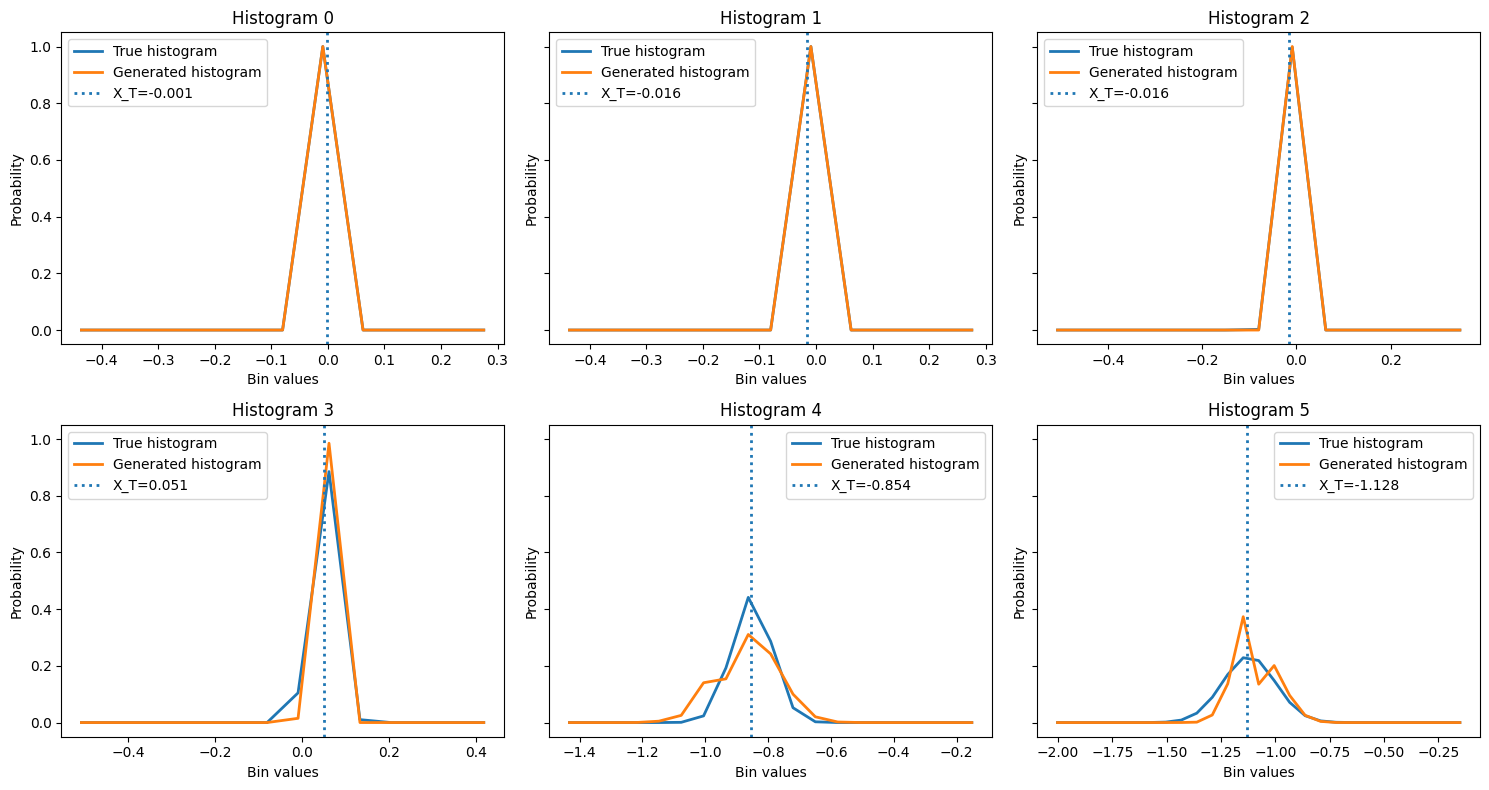

In [7]:
#generated_sample = generated[-1]
#true_sample = pdfs[-1]
#plot_bin_dist(true_sample, generated_sample, bins, Xt[-1])

plot_bin_dist(pdfs, generated, bins, Xt, ncols=3)



# FORGAN simple

In [9]:
# to train a forgan we simulate the J trajectories and the target output is given by the 1-step ahead value
# so just the path are generated and the last values of each trajectory is used as target 
# at inference time the pdf is the one at 1 day ahead
X0_range = (0.0,0.0)
mu_range = (0.0, 0.0)
sigma_range = (0.005, 0.8)
T = 1.0        # Time horizon (1 year)
N = 253        # Number of time steps
J = 100000        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

trajectories = sim.get_paths()
paths = trajectories[:, :-1] #shape JxN-1
targets= trajectories[:, -1:] #shape Jx1
pdfs = sim.get_pdf(n_bins=100, P=paths[:, -1], n_steps_ahead=1)
sim.save_configuration('./models/bins/forgan_simple.json')

Bins saved to models\bins\forgan_simple.json


In [ ]:
mydata, _, _ = prepare_data(targets, paths)

generator_params = {"hidden_dims": [512, 256, 128, 64], "use_batch_norm":True}
critic_params = {"hidden_dims": [512, 256, 256, 128, 64], 'use_layer_norm':False}
conditional_gan = MyCGAN(max_epoch=100, name='forgan_simple', z_noise_dim=64)
conditional_gan.set_generator(condition_size=paths.shape[1], output_dim=targets.shape[1], **generator_params)
conditional_gan.set_discriminator(input_size=targets.shape[1], condition_size=paths.shape[1], **critic_params)
conditional_gan.train(mydata, save_history=True)
conditional_gan.save_models() 
stats = conditional_gan.evaluate_error_distribution(mydata, is_prob=False, save_to='forgan_simple.csv')


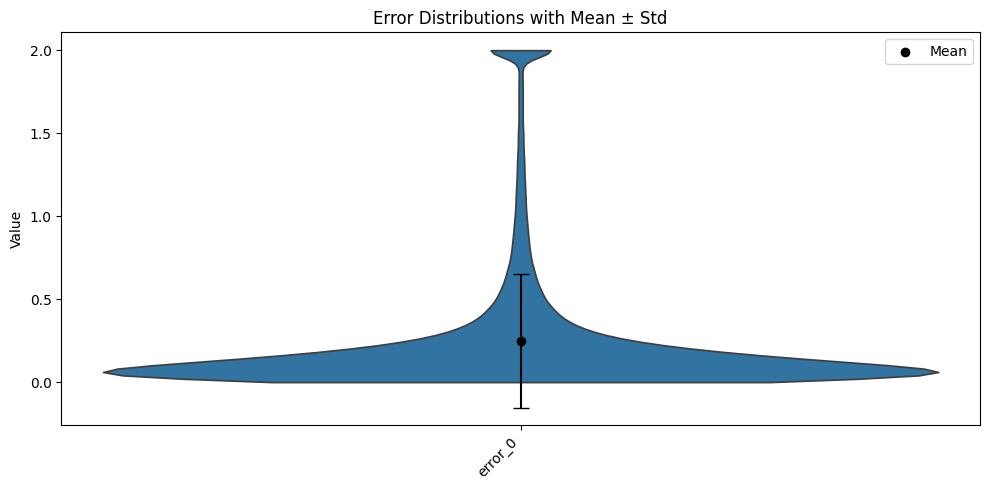

error_0    0.247726
dtype: float64 
 error_0    0.401025
dtype: float64 
              mean       std    median      skew   kurtosis  is_zero_test  \
error_0  0.247726  0.401025  0.112539  3.155226  10.000242         False   

                                confidence_interval  
error_0  (0.24523996364248796, 0.25021109187599544)  


In [3]:
means, std, summary = analyze_error_distribution('./data/results/forgan_simple.csv')
print(means,'\n', std, '\n', summary)

## ks test

In [2]:
# data simulation 
# example

X0_range = (0.0, 0.0)
mu_range = (0.0, 0.0)
sigma_range = (0.01, 0.7)
T = 1.0        # Time horizon (1 year)
N = 253        # Number of time steps
J = 1000       # Number of paths to simulate
SEED=2

#generate
val = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

val.load_configuration('./models/bins/forgan_simple.json')
trajectories = val.get_paths()
paths = trajectories[:, :-1] #shape JxN-1
targets= trajectories[:, -1:] #shape Jx1
pdfs = val.get_pdf(n_steps_ahead=1, P=paths[:, -1])
Xt = val.X_T
bins = val.bins

conditional_gan = MyCGAN(max_epoch=100, name='forgan_simple')
conditional_gan.load_models()



mydata, _, _ = prepare_data(targets, paths)
condition, generated = conditional_gan.generate(mydata, get_pdf=True, bins = bins)



p_values = []
for i, row in enumerate(pdfs):
    _, p_value = ks_test_gan_cdf(generated[i], row)
    p_values.append(p_value)

test_df = pd.DataFrame({'p_values':p_values})
test_h0 = test_df[test_df['p_values']>0.01]
print(len(test_h0)/len(test_df))






Bins loaded from models\bins\forgan_simple.json
Loaded 101 bins
CGAN config loaded from ./models\forgan_simple_config.json
Generator loaded from ./models\forgan_simple_generator.pth
Architecture: MyGenerator
Parameters: {'latent_size': 64, 'condition_size': 253, 'output_dim': 1, 'hidden_dims': [512, 256, 128, 64], 'is_prob': False, 'use_batch_norm': True, 'activation': 'relu', 'dropout': 0.0}
Discriminator loaded from ./models\forgan_simple_discriminator.pth
Architecture: MyDiscriminator
Parameters: {'input_size': 1, 'condition_size': 253, 'output_dim': 1, 'hidden_dims': [512, 256, 256, 128, 64], 'use_layer_norm': False, 'activation': 'leaky_relu', 'dropout': 0.0}
shape array (1000, 1000)
0.384


In [4]:
# data simulation 
# example

X0_range = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
mu_range = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
sigma_range = [0.005, 0.01, 0.05, 0.1, 0.3, 0.6]
T = 1.0        # Time horizon (1 year)
N = 253        # Number of time steps
J = 6       # Number of paths to simulate
SEED=2

#generate
val = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

val.load_configuration('./models/bins/forgan_simple.json')
trajectories = val.get_paths()
paths = trajectories[:, :-1] #shape JxN-1
targets= trajectories[:, -1:] #shape Jx1
pdfs = val.get_pdf(n_steps_ahead=1, P=paths[:, -1])
Xt = val.X_T
bins = val.bins





Bins loaded from models\bins\forgan_simple.json
Loaded 101 bins


In [5]:
conditional_gan = MyCGAN(max_epoch=100, name='forgan_simple')
conditional_gan.load_models()

CGAN config loaded from ./models\forgan_simple_config.json
Generator loaded from ./models\forgan_simple_generator.pth
Architecture: MyGenerator
Parameters: {'latent_size': 64, 'condition_size': 253, 'output_dim': 1, 'hidden_dims': [512, 256, 128, 64], 'is_prob': False, 'use_batch_norm': True, 'activation': 'relu', 'dropout': 0.0}
Discriminator loaded from ./models\forgan_simple_discriminator.pth
Architecture: MyDiscriminator
Parameters: {'input_size': 1, 'condition_size': 253, 'output_dim': 1, 'hidden_dims': [512, 256, 256, 128, 64], 'use_layer_norm': False, 'activation': 'leaky_relu', 'dropout': 0.0}


In [6]:

mydata, _, _ = prepare_data(targets, paths)
condition, generated = conditional_gan.generate(mydata, get_pdf=True, bins = bins)



p_values = []
for i, row in enumerate(pdfs):
    _, p_value = ks_test_gan_cdf(generated[i], row)
    p_values.append(p_value)

test_df = pd.DataFrame({'p_values':p_values})
test_df



shape array (1, 6, 1000)


,p_values
0,1.000000e+00
1,1.000000e+00
2,1.010006e-01
3,1.000000e+00
4,3.841746e-04
5,1.529030e-31


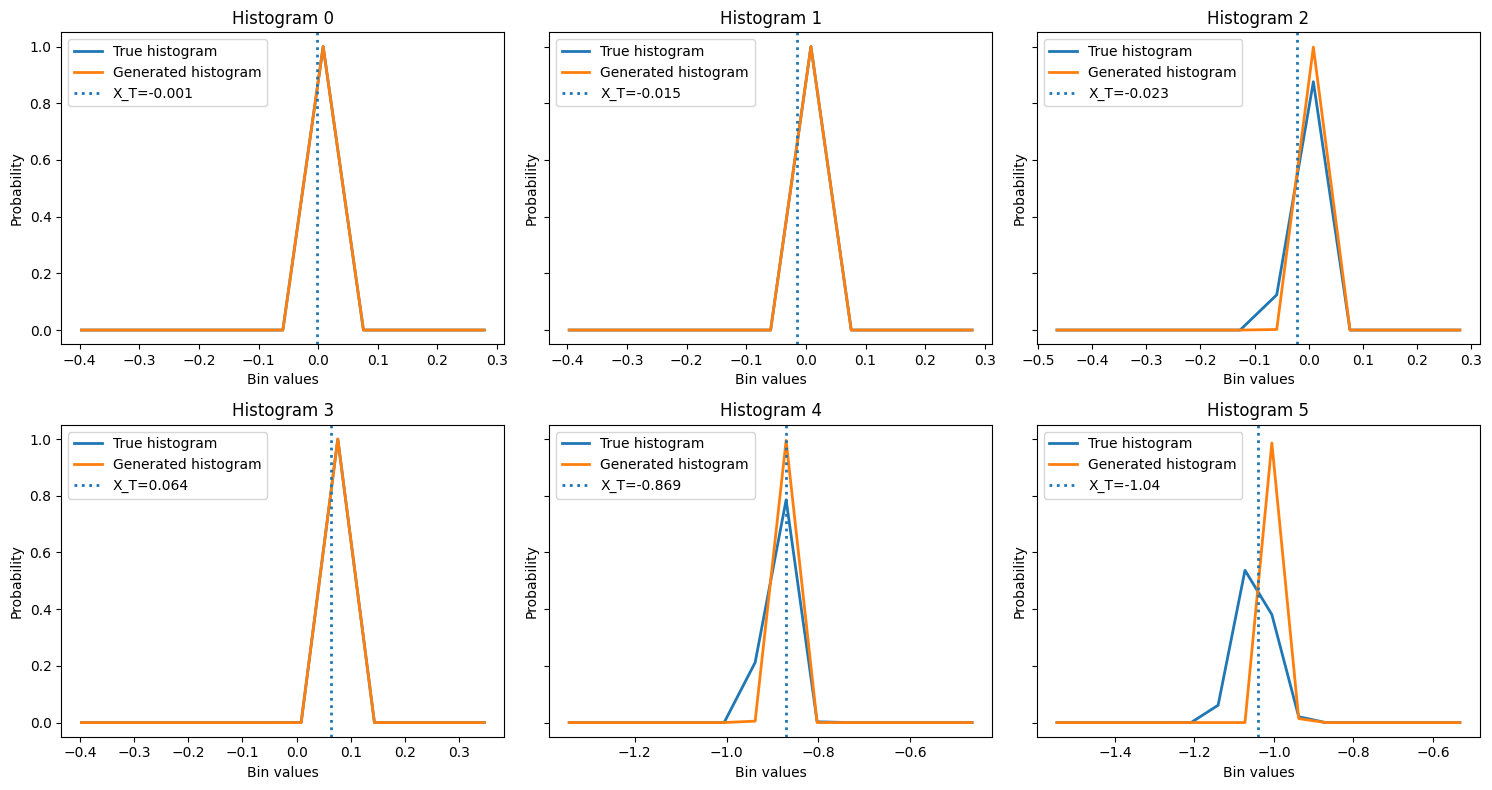

In [7]:
plot_bin_dist(pdfs, generated, bins, Xt, ncols=3)

# FORGAN

In [8]:
# to train a forgan we simulate the J trajectories and the target output is given by the 1-step ahead value
# so just the path are generated and the last values of each trajectory is used as target 
# at inference time the pdf is the one at 1 day ahead
X0_range = (0.0,0.0)
mu_range = (0.0, 0.0)
sigma_range = (0.005, 0.8)
T = 1.0        # Time horizon (1 year)
N = 253        # Number of time steps
J = 100000        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

trajectories = sim.get_paths()
paths = trajectories[:, :-1] #shape JxN-1
targets= trajectories[:, -1:] #shape Jx1
pdfs = sim.get_pdf(n_bins=100, P=paths[:, -1], n_steps_ahead=1)
sim.save_configuration('./models/bins/forgan_v3.json')
targets

Bins saved to models\bins\forgan_v3.json


array([[-0.17398272],
       [ 0.21292914],
       [-0.45064334],
       ...,
       [ 0.96204068],
       [-0.14194661],
       [-0.08341593]], shape=(100000, 1))

In [ ]:
mydata, _, _ = prepare_data(targets, paths)

generator_params = {"hidden_dims": [512, 256, 128, 64], "use_batch_norm":False}
critic_params = {"hidden_dims": [512, 256, 256, 128, 64], 'use_layer_norm':True}
conditional_gan = MyCWGAN(max_epoch=100, name='forgan_v3', z_noise_dim=64)
conditional_gan.set_generator(condition_size=paths.shape[1], output_dim=targets.shape[1], **generator_params)
conditional_gan.set_discriminator(input_size=targets.shape[1], condition_size=paths.shape[1], **critic_params)
conditional_gan.train(mydata, save_history=True, early_stopping_waiting=100)
conditional_gan.save_models() 
stats = conditional_gan.evaluate_error_distribution(mydata, is_prob=False, save_to='forgan_v3.csv')


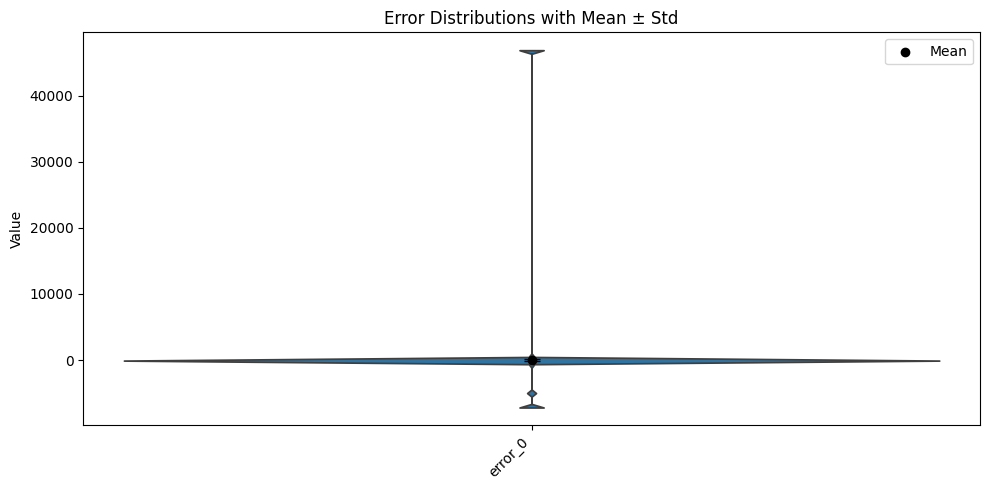

error_0    0.33918
dtype: float64 
 error_0    153.497078
dtype: float64 
             mean         std    median        skew      kurtosis  \
error_0  0.33918  153.497078 -0.026294  284.653331  86965.459361   

         is_zero_test                        confidence_interval  
error_0          True  (-0.6121983947104437, 1.2905591652713824)  


In [10]:
means, std, summary = analyze_error_distribution('./data/results/forgan_v3.csv')
print(means,'\n', std, '\n', summary)

## KS test 

In [3]:
# data simulation 
# example

X0_range = (0.0, 0.0)
mu_range = (0.0, 0.0)
sigma_range = (0.01, 0.7)
T = 1.0        # Time horizon (1 year)
N = 253        # Number of time steps
J = 1000       # Number of paths to simulate
SEED=2

#generate
val = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

val.load_configuration('./models/bins/forgan_v3.json')
trajectories = val.get_paths()
paths = trajectories[:, :-1] #shape JxN-1
targets= trajectories[:, -1:] #shape Jx1
pdfs = val.get_pdf(n_steps_ahead=1, P=paths[:, -1])
Xt = val.X_T
bins = val.bins

conditional_gan = MyCWGAN(max_epoch=100, name='forgan_v3')
conditional_gan.load_models()



mydata, _, _ = prepare_data(targets, paths)
condition, generated = conditional_gan.generate(mydata, get_pdf=True, bins = bins)



p_values = []
for i, row in enumerate(pdfs):
    _, p_value = ks_test_gan_cdf(generated[i], row)
    p_values.append(p_value)

test_df = pd.DataFrame({'p_values':p_values})
test_h0 = test_df[test_df['p_values']>0.01]
print(len(test_h0)/len(test_df))






Bins loaded from models\bins\forgan_v3.json
Loaded 101 bins
CGAN config loaded from ./models\forgan_v3_config.json
Generator loaded from ./models\forgan_v3_generator.pth
Architecture: MyGenerator
Parameters: {'latent_size': 64, 'condition_size': 253, 'output_dim': 1, 'hidden_dims': [512, 256, 128, 64], 'is_prob': False, 'use_batch_norm': False, 'activation': 'relu', 'dropout': 0.0}
Discriminator loaded from ./models\forgan_v3_discriminator.pth
Architecture: MyDiscriminator
Parameters: {'input_size': 1, 'condition_size': 253, 'output_dim': 1, 'hidden_dims': [512, 256, 256, 128, 64], 'use_layer_norm': True, 'activation': 'leaky_relu', 'dropout': 0.0}
shape array (1000, 1000)
0.451


### visual

In [2]:
# data simulation 
# example

X0_range = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
mu_range = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
sigma_range = [0.005, 0.01, 0.05, 0.1, 0.3, 0.6]
T = 1.0        # Time horizon (1 year)
N = 253        # Number of time steps
J = 6       # Number of paths to simulate
SEED=2

#generate
val = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

val.load_configuration('./models/bins/forgan_v3.json')
trajectories = val.get_paths()
paths = trajectories[:, :-1] #shape JxN-1
targets= trajectories[:, -1:] #shape Jx1
pdfs = val.get_pdf(n_steps_ahead=1, P=paths[:, -1])
Xt = val.X_T
bins = val.bins





Bins loaded from models\bins\forgan_v3.json
Loaded 101 bins


In [3]:
conditional_gan = MyCGAN(max_epoch=100, name='forgan_v3')
conditional_gan.load_models()

CGAN config loaded from ./models\forgan_v3_config.json
Generator loaded from ./models\forgan_v3_generator.pth
Architecture: MyGenerator
Parameters: {'latent_size': 64, 'condition_size': 253, 'output_dim': 1, 'hidden_dims': [512, 256, 128, 64], 'is_prob': False, 'use_batch_norm': False, 'activation': 'relu', 'dropout': 0.0}
Discriminator loaded from ./models\forgan_v3_discriminator.pth
Architecture: MyDiscriminator
Parameters: {'input_size': 1, 'condition_size': 253, 'output_dim': 1, 'hidden_dims': [512, 256, 256, 128, 64], 'use_layer_norm': True, 'activation': 'leaky_relu', 'dropout': 0.0}


In [4]:

mydata, _, _ = prepare_data(targets, paths)
condition, generated = conditional_gan.generate(mydata, get_pdf=True, bins = bins)



p_values = []
for i, row in enumerate(pdfs):
    _, p_value = ks_test_gan_cdf(generated[i], row)
    p_values.append(p_value)

test_df = pd.DataFrame({'p_values':p_values})
test_df



shape array (1, 6, 1000)


,p_values
0,0.999829
1,0.000272
2,0.001860
3,0.045173
4,0.023796
5,0.000336


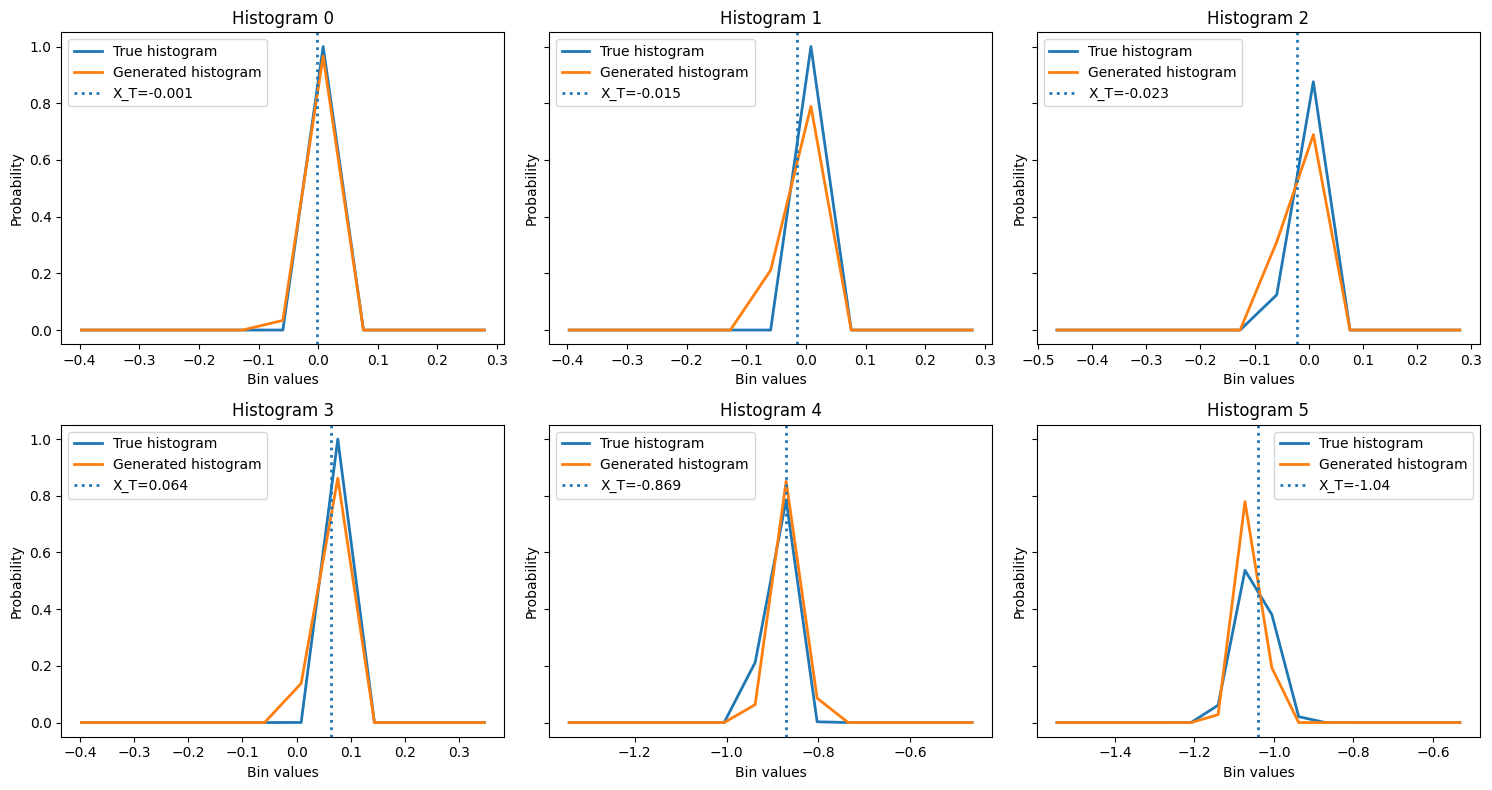

In [5]:
plot_bin_dist(pdfs, generated, bins, Xt, ncols=3)